In [69]:

import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import auc,classification_report, roc_auc_score, roc_curve
import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.base import is_classifier
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.colors as mcolors
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression


### Colors 

In [70]:
sns.set_theme(style="whitegrid", palette="Greys_r")
plt.rcParams["figure.figsize"] = (12, 6)   # más compactas
plt.rcParams["figure.dpi"] = 100

red_grey = mcolors.LinearSegmentedColormap.from_list(
    "RedGrey",
    ["#bfbfbf96", "#c60f0f"]  # gris → rojo
)

### Funciones 

In [ ]:
from src.visualization.viz import plot_macro_roc, plot_global_roc, plot_roc_curve_multiclass , shap_multiclass_full_report , plot_probability_histogram, plot_probability_density, plot_xgb_importance

---

In [72]:
df = pd.read_csv("data/clean_train.csv")

mapping = {
    "Poor": 0,
    "Standard": 1,
    "Good": 2
}

y = df["Credit_Score"].map(mapping)


X = df.drop("Credit_Score", axis=1)

X = pd.get_dummies(X, drop_first=True).astype(float)

selected_features = [
    'Outstanding_Debt',
    'Interest_Rate',
    'Delay_from_due_date',
    'Num_Credit_Card',
    'Changed_Credit_Limit',
    'Total_EMI_per_month',
    'Credit_Mix_Standard',
    'Credit_Mix_Good',
    'Payment_of_Min_Amount_Yes'
]

X = X[selected_features]

### Modelo 

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42, stratify=y)

model = XGBClassifier(
    objective="multi:softprob",   
    num_class=3,                  
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.6,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42
)

model.fit(X_train,y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro"))


              precision    recall  f1-score   support

           0       0.77      0.75      0.76      5799
           1       0.79      0.80      0.79     10635
           2       0.71      0.71      0.71      3566

    accuracy                           0.77     20000
   macro avg       0.76      0.75      0.76     20000
weighted avg       0.77      0.77      0.77     20000

AUC: 0.8956157671153622


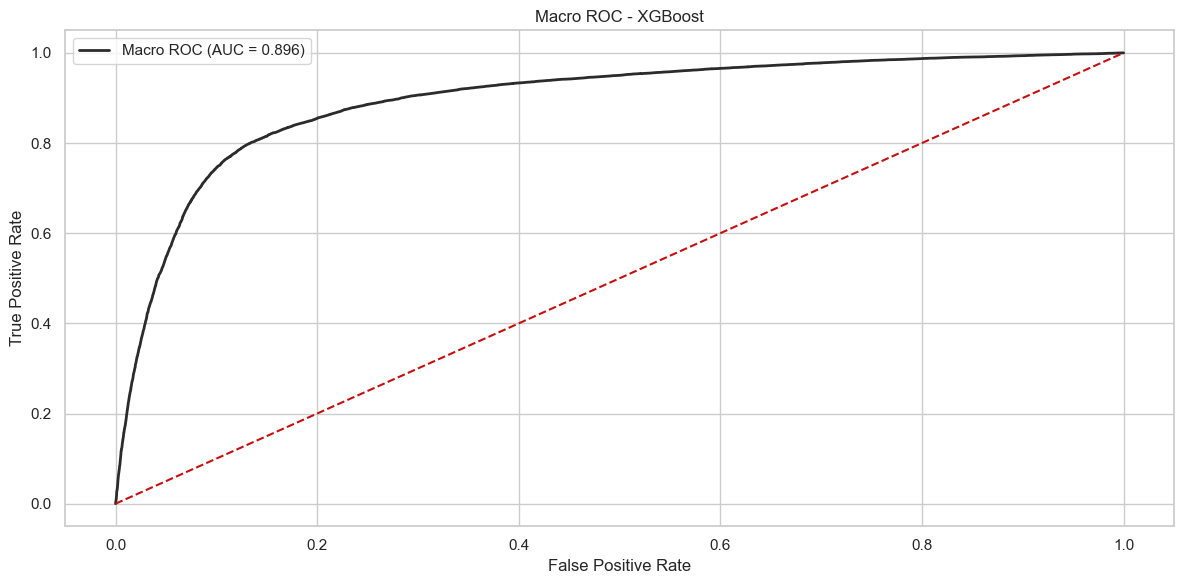

0.8956372559028607

In [74]:
plot_macro_roc(y_test, y_proba, model_name="XGBoost")

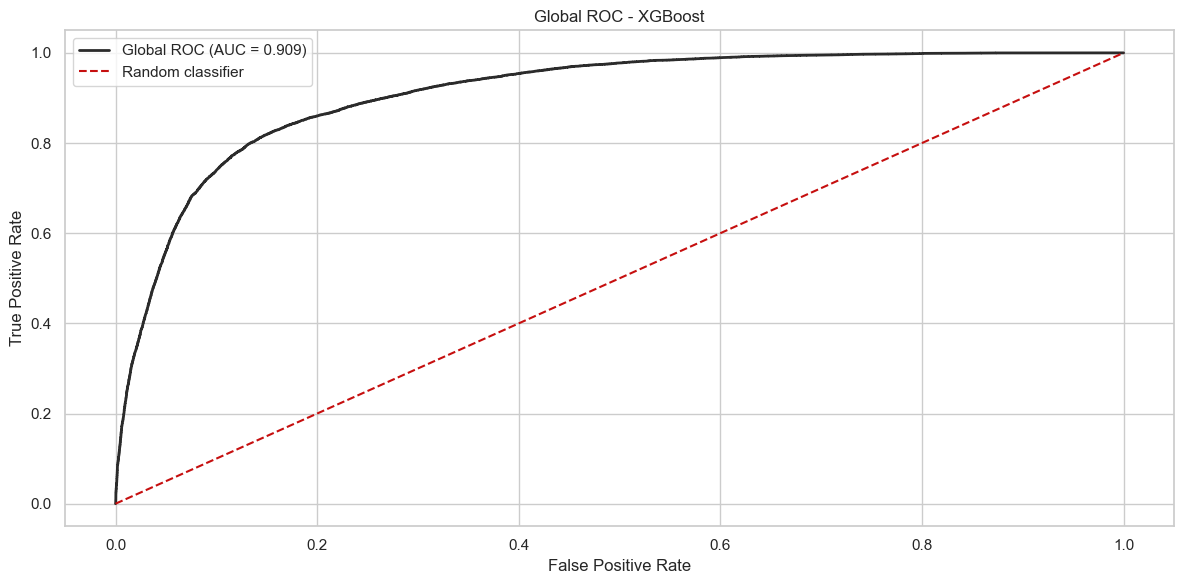

0.9094505049999999

In [75]:
plot_global_roc(y_test, y_proba, model_name="XGBoost")

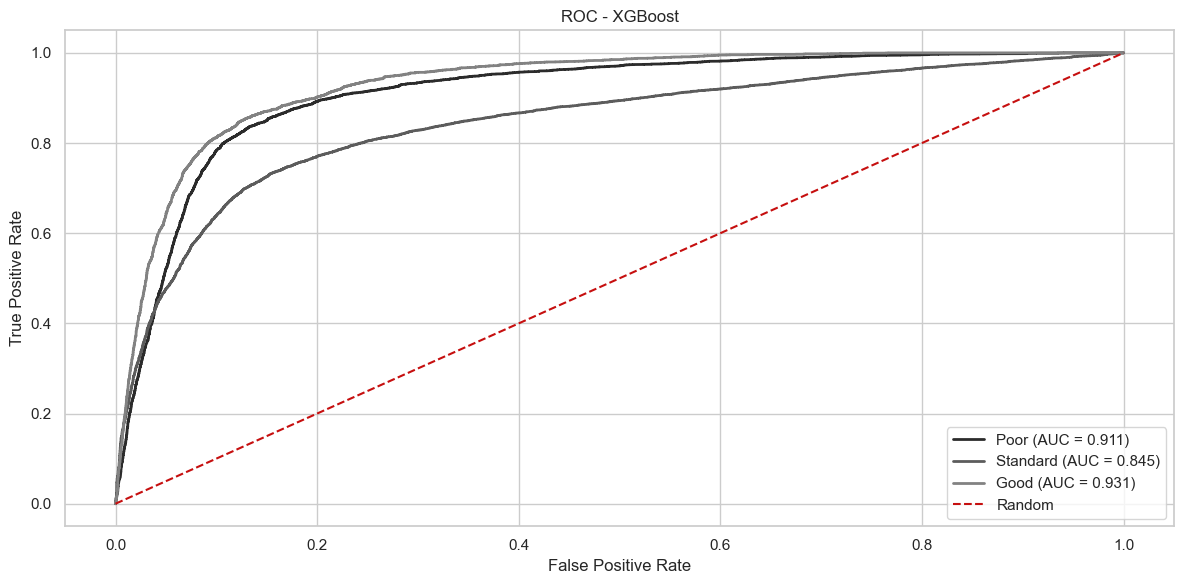

In [76]:
plot_roc_curve_multiclass(y_test, y_proba, model_name="XGBoost") 

In [77]:
explainer = shap.TreeExplainer(model)
raw_shap = explainer.shap_values(X_test)

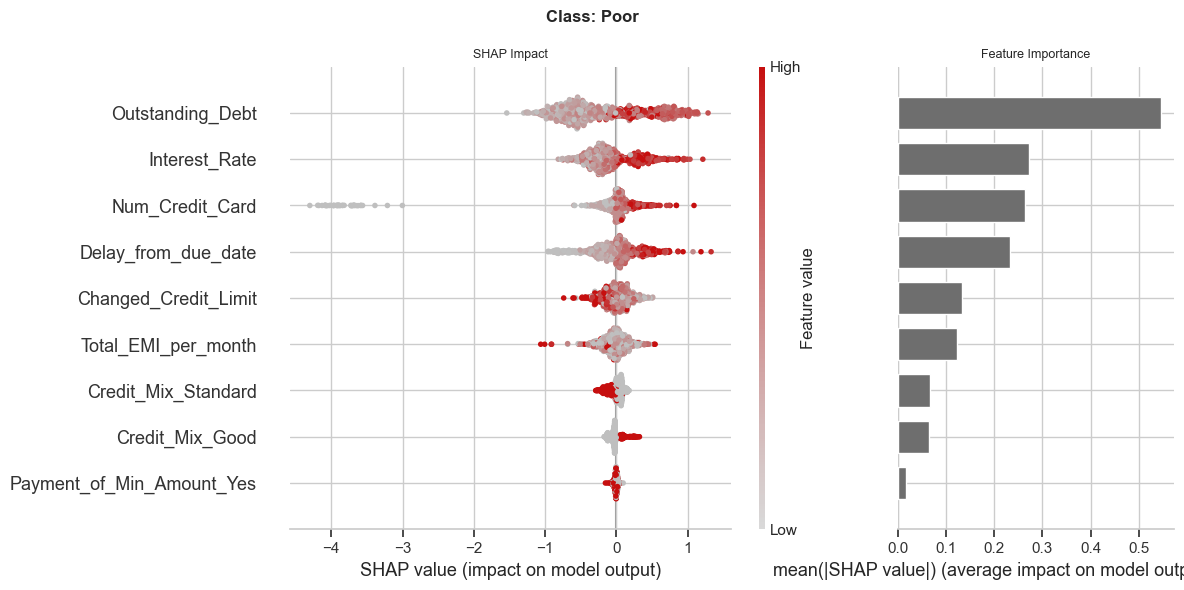

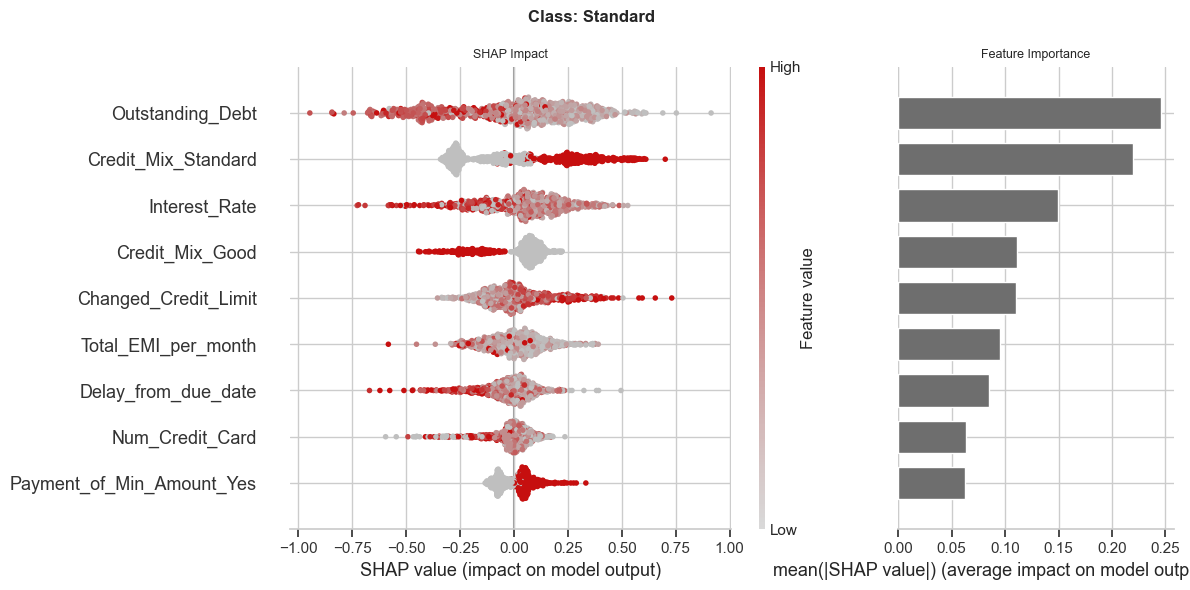

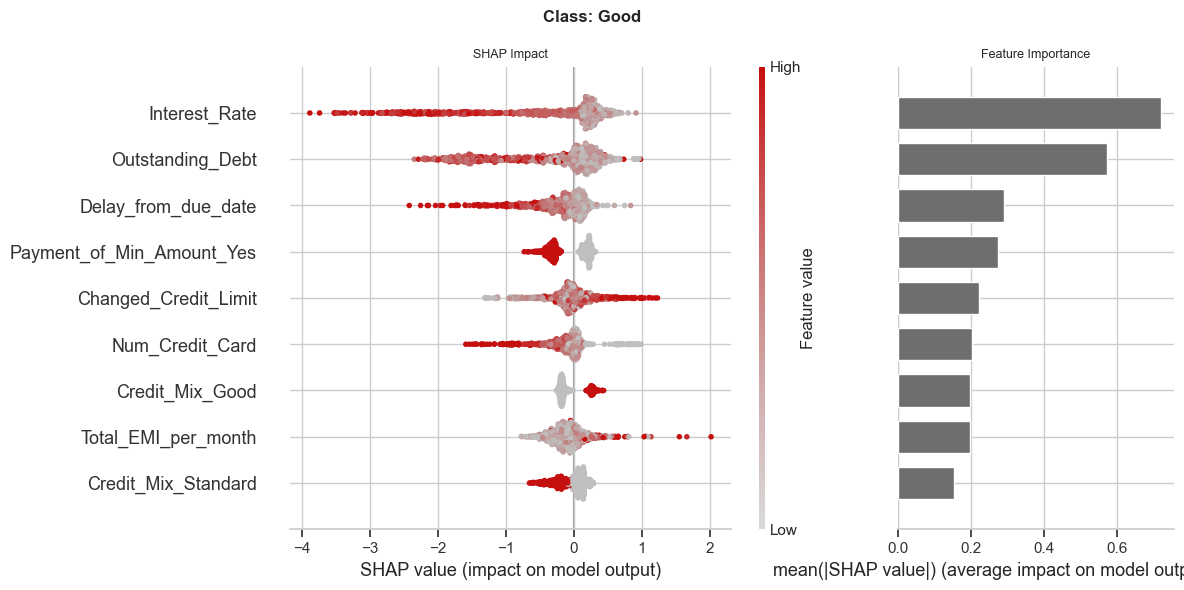

<Figure size 1200x600 with 0 Axes>

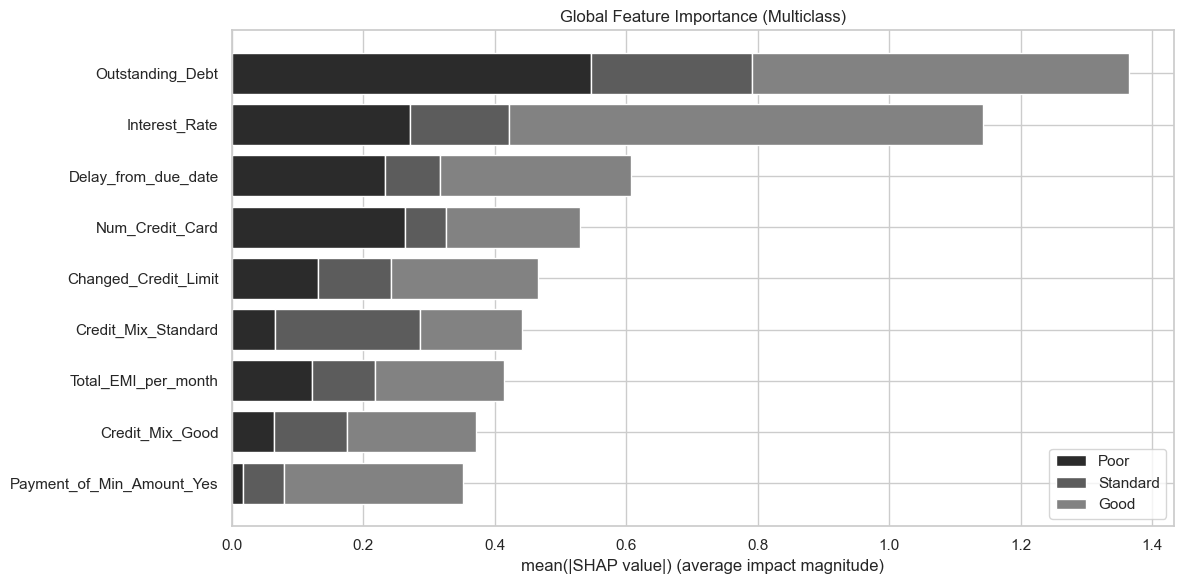

In [78]:
shap_multiclass_full_report(
    model=model,
    X=X_test,
    class_names=("Poor","Standard","Good"),
    top_n=10,
    sample_size=1000,
)

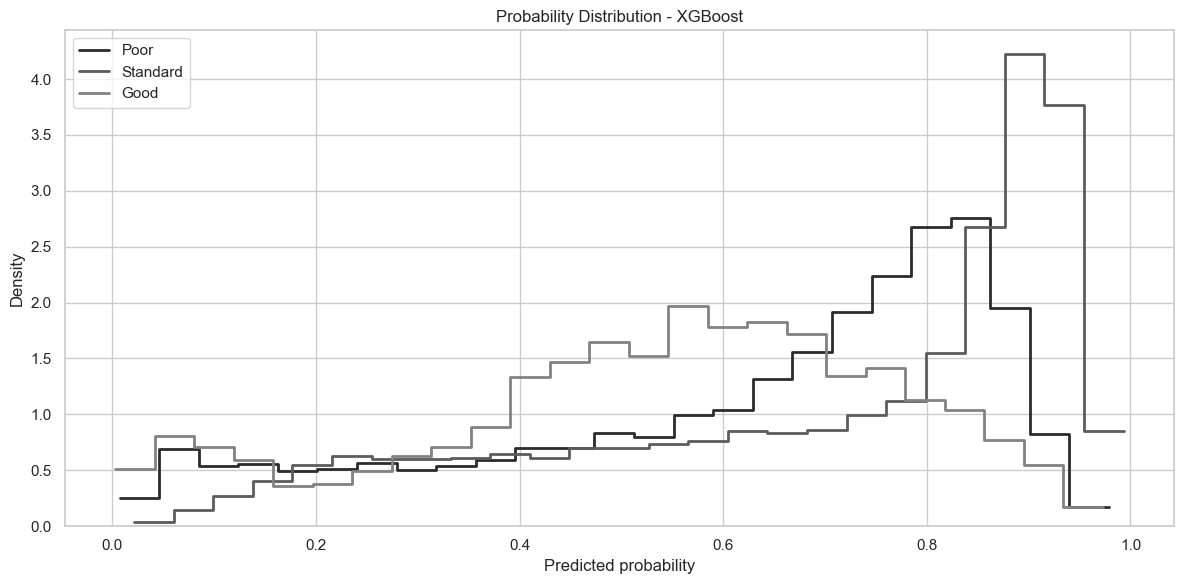

In [79]:
plot_probability_histogram(
    y_test,
    y_proba,
    model_name="XGBoost"
)

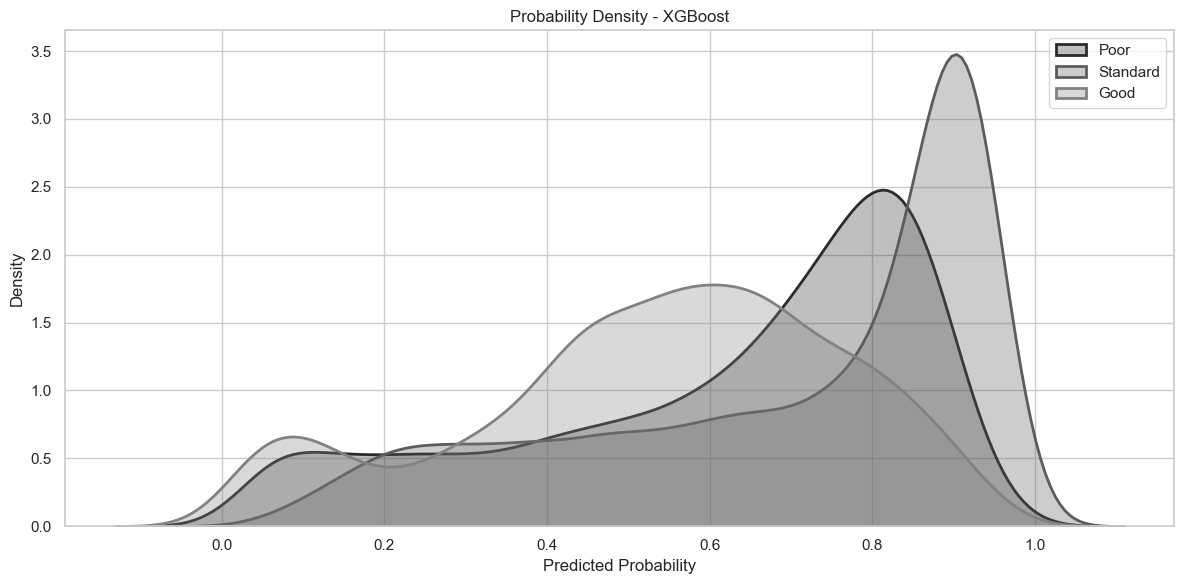

In [80]:
plot_probability_density(
    y_test,
    y_proba,
    model_name="XGBoost"
)

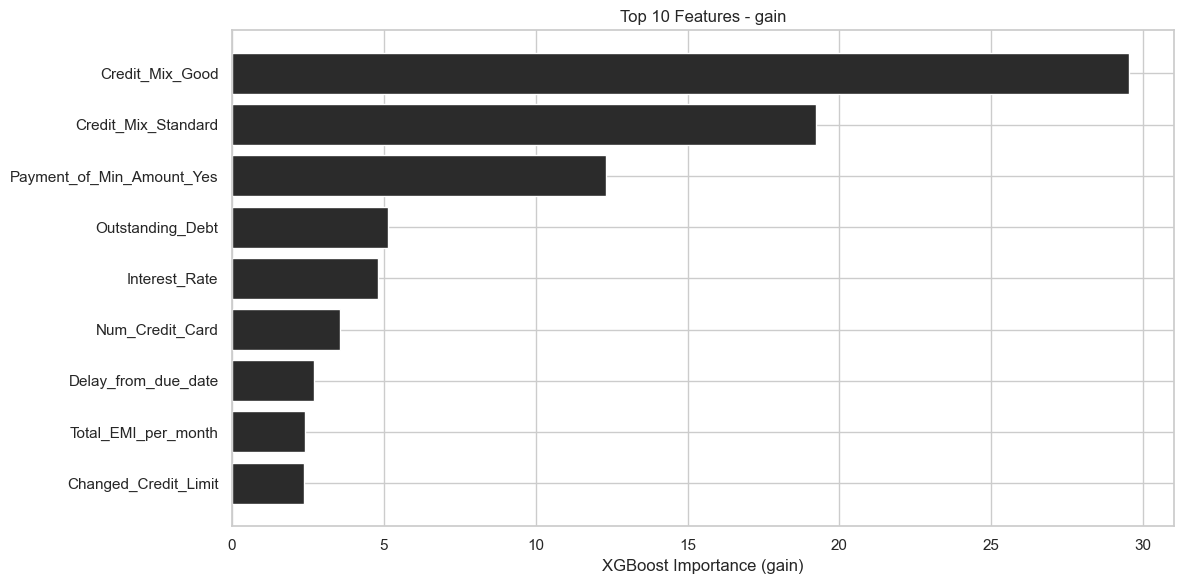

In [81]:
plot_xgb_importance(model, X_train, importance_type="gain")

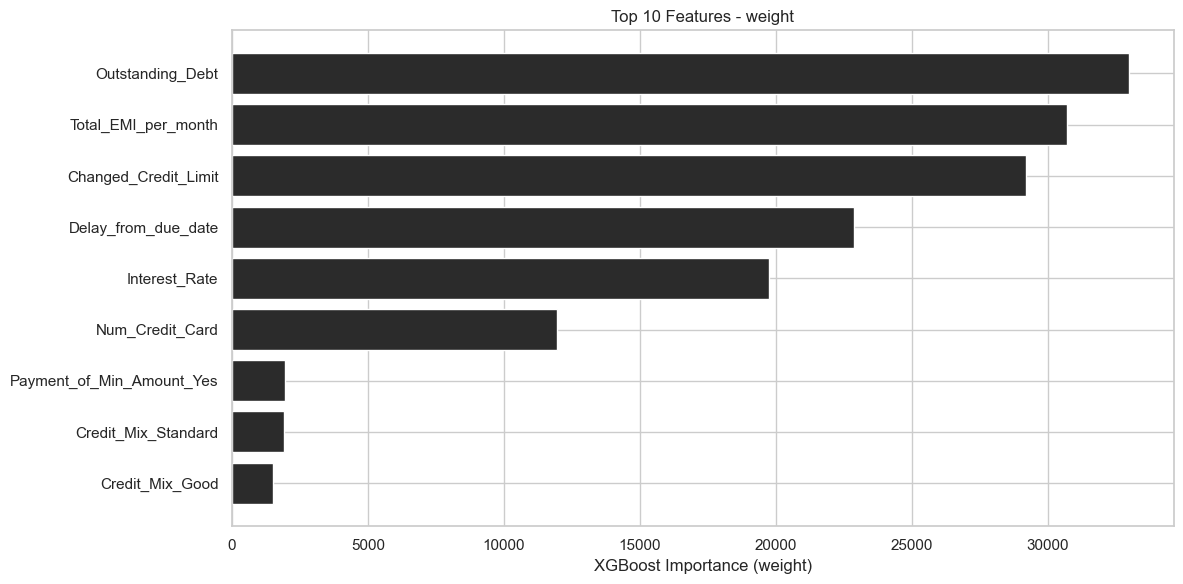

In [82]:
plot_xgb_importance(model, X_train, importance_type="weight")

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

final_features = [
    'Outstanding_Debt',
    'Interest_Rate',
    'Delay_from_due_date',
    'Num_Credit_Card',
    'Changed_Credit_Limit',
    'Total_EMI_per_month',
    'Credit_Mix_Standard',
    'Credit_Mix_Good',
    'Payment_of_Min_Amount_Yes'
]

X_model = X[final_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=10000, class_weight='balanced', random_state=42)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))


Accuracy: 0.64565
              precision    recall  f1-score   support

           0       0.63      0.66      0.65      5874
           1       0.79      0.58      0.67     10599
           2       0.48      0.82      0.60      3527

    accuracy                           0.65     20000
   macro avg       0.63      0.69      0.64     20000
weighted avg       0.69      0.65      0.65     20000



In [88]:

accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", accuracy)


Logistic Regression Accuracy: 0.64565


In [89]:
from sklearn.metrics import confusion_matrix


print(classification_report(y_test, y_pred))


confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.63      0.66      0.65      5874
           1       0.79      0.58      0.67     10599
           2       0.48      0.82      0.60      3527

    accuracy                           0.65     20000
   macro avg       0.63      0.69      0.64     20000
weighted avg       0.69      0.65      0.65     20000



array([[3876, 1104,  894],
       [2163, 6152, 2284],
       [  88,  554, 2885]])